<a href="https://colab.research.google.com/github/aabyyaann/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter7_Working_with_Text_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 - Working with Text Data

**Book Reference:** *Introduction to Machine Learning with Python*  
**Author:** Andreas C. Müller & Sarah Guido  

Notebook ini membahas bagaimana data teks diubah menjadi fitur numerik agar bisa diproses oleh model machine learning.  
Topik utama pada chapter ini meliputi:

1. Representasi teks dengan **bag-of-words**
2. Penggunaan **CountVectorizer**
3. Penggunaan **TF-IDF**
4. Klasifikasi sentimen pada dataset ulasan film
5. Evaluasi model untuk data teks
6. Pengaruh parameter vectorizer seperti `min_df`, `ngram_range`, dan `stop_words`
7. Interpretasi fitur kata yang paling penting dalam model linear

Chapter ini penting karena sebagian besar data di dunia nyata berbentuk teks, misalnya review, komentar, email, berita, dan dokumen.

## 1. Tujuan Chapter 7

Pada data numerik, setiap fitur sudah berupa angka sehingga model bisa langsung memprosesnya.  
Namun pada data teks, komputer tidak bisa langsung memahami kalimat seperti:

- "This movie is great"
- "The film was boring"

Karena itu, teks harus diubah terlebih dahulu menjadi representasi numerik.  
Salah satu pendekatan paling umum adalah **bag-of-words**, yaitu menghitung kemunculan kata dalam dokumen.

Pada chapter ini kita akan melihat alur umum text mining:

**Raw text → preprocessing → vectorization → training model → evaluation → interpretation**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

import os
import tarfile
import urllib.request

print("Library Chapter 7 berhasil diimport.")

Library Chapter 7 berhasil diimport.


## 2. Dataset yang digunakan

Pada chapter ini, contoh utama menggunakan **IMDb movie reviews dataset** untuk klasifikasi sentimen.

Tugas model:
- memprediksi apakah review film bernilai **positif**
- atau **negatif**

Karena dataset IMDb tidak selalu tersedia langsung di Colab, kita akan mencoba mengunduhnya terlebih dahulu.  
Jika berhasil, dataset akan dibaca dari folder `aclImdb`.

In [2]:
# Download dataset IMDb jika belum ada
imdb_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
imdb_tar = "aclImdb_v1.tar.gz"
imdb_folder = "aclImdb"

if not os.path.exists(imdb_folder):
    print("Mengunduh dataset IMDb...")
    urllib.request.urlretrieve(imdb_url, imdb_tar)
    print("Ekstrak dataset...")
    with tarfile.open(imdb_tar, "r:gz") as tar:
        tar.extractall()
    print("Dataset selesai diunduh dan diekstrak.")
else:
    print("Dataset IMDb sudah tersedia.")

Mengunduh dataset IMDb...
Ekstrak dataset...


/tmp/ipykernel_931/2070046372.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Dataset selesai diunduh dan diekstrak.


## 3. Memuat data training dan test

Dataset IMDb sudah dibagi menjadi dua folder besar:

- `train/`
- `test/`

Masing-masing berisi dua kategori:
- `pos` → review positif
- `neg` → review negatif

Kita akan membaca folder tersebut menggunakan `load_files()` dari scikit-learn.

In [3]:
reviews_train = load_files(os.path.join(imdb_folder, "train"))
text_train, y_train = reviews_train.data, reviews_train.target

reviews_test = load_files(os.path.join(imdb_folder, "test"))
text_test, y_test = reviews_test.data, reviews_test.target

print("Jumlah data train :", len(text_train))
print("Jumlah data test  :", len(text_test))
print("Label classes     :", reviews_train.target_names)

Jumlah data train : 75000
Jumlah data test  : 25000
Label classes     : ['neg', 'pos', 'unsup']


In [4]:
print("Contoh review pertama (raw bytes):")
print(text_train[0][:500])
print("\nLabel review pertama:", y_train[0])

Contoh review pertama (raw bytes):
b'Full of (then) unknown actors TSF is a great big cuddly romp of a film.<br /><br />The idea of a bunch of bored teenagers ripping off the local sink factory is odd enough, but add in the black humour that Forsyth & Co are so good at and your in for a real treat.<br /><br />The comatose van driver by itself worth seeing, and the canal side chase is just too real to be anything but funny.<br /><br />And for anyone who lived in Glasgow it\'s a great "Oh I know where that is" film.'

Label review pertama: 2


## 4. Mengubah data bytes menjadi string

Sering kali data teks dibaca dalam format **bytes**.  
Agar lebih mudah diproses dan dibaca, kita ubah menjadi string menggunakan decoding UTF-8.

In [5]:
text_train = [doc.decode("utf-8", errors="ignore") for doc in text_train]
text_test = [doc.decode("utf-8", errors="ignore") for doc in text_test]

print("Contoh review setelah decoding:")
print(text_train[0][:500])

Contoh review setelah decoding:
Full of (then) unknown actors TSF is a great big cuddly romp of a film.<br /><br />The idea of a bunch of bored teenagers ripping off the local sink factory is odd enough, but add in the black humour that Forsyth & Co are so good at and your in for a real treat.<br /><br />The comatose van driver by itself worth seeing, and the canal side chase is just too real to be anything but funny.<br /><br />And for anyone who lived in Glasgow it's a great "Oh I know where that is" film.


## 5. Memahami Bag-of-Words

Pendekatan **bag-of-words** mengubah dokumen menjadi vektor angka berdasarkan kata yang muncul.

Misalnya ada dua kalimat:

1. "I love this movie"
2. "I hate this movie"

Vocabulary yang terbentuk bisa menjadi:
- I
- love
- this
- movie
- hate

Lalu tiap dokumen direpresentasikan sebagai jumlah kemunculan kata-kata tersebut.

Kelebihan pendekatan ini:
- sederhana
- efektif
- banyak dipakai sebagai baseline kuat

Kekurangannya:
- tidak memahami urutan kata
- tidak memahami makna semantik secara mendalam

In [6]:
bards_words = ["The fool doth think he is wise,",
               "but the wise man knows himself to be a fool"]

In [7]:
vect = CountVectorizer()
vect.fit(bards_words)

print("Vocabulary size:", len(vect.vocabulary_))
print("Vocabulary content:")
print(vect.vocabulary_)

Vocabulary size: 13
Vocabulary content:
{'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


In [8]:
bag_of_words = vect.transform(bards_words)

print("Tipe data hasil transform:", type(bag_of_words))
print("Shape matrix:", bag_of_words.shape)
print("Isi matrix bag-of-words:")
print(bag_of_words.toarray())

Tipe data hasil transform: <class 'scipy.sparse._csr.csr_matrix'>
Shape matrix: (2, 13)
Isi matrix bag-of-words:
[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


## 6. Penjelasan hasil CountVectorizer

Setelah `CountVectorizer` di-fit pada kumpulan teks:
- model membuat **vocabulary**, yaitu daftar semua kata unik
- setiap dokumen diubah menjadi vektor angka
- setiap kolom merepresentasikan satu kata
- nilainya adalah jumlah kemunculan kata tersebut

Karena kebanyakan dokumen hanya memuat sebagian kecil dari semua kata, matriks hasil biasanya berbentuk **sparse matrix**.
Sparse matrix sangat penting karena menghemat memori untuk data teks berukuran besar.

## 7. CountVectorizer pada dataset IMDb

Sekarang kita terapkan `CountVectorizer` ke data review film.  
Tujuannya adalah mengubah ribuan dokumen teks menjadi fitur numerik yang bisa dipakai model klasifikasi.

In [9]:
vect = CountVectorizer()
X_train = vect.fit_transform(text_train)
X_test = vect.transform(text_test)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (75000, 124255)
X_test shape : (25000, 124255)


In [10]:
feature_names = vect.get_feature_names_out()

print("Jumlah kata dalam vocabulary:", len(feature_names))
print("20 kata pertama:")
print(feature_names[:20])

print("\n20 kata di tengah vocabulary:")
mid = len(feature_names) // 2
print(feature_names[mid:mid+20])

print("\n20 kata terakhir:")
print(feature_names[-20:])

Jumlah kata dalam vocabulary: 124255
20 kata pertama:
['00' '000' '0000' '0000000000000000000000000000000001' '0000000000001'
 '000000001' '000000003' '00000001' '000001745' '00001' '0001' '00015'
 '0002' '0007' '00083' '000ft' '000s' '000th' '001' '002']

20 kata di tengah vocabulary:
['lacked' 'lackey' 'lackeys' 'lackies' 'lacking' 'lacklusted' 'lackluster'
 'lacklustre' 'lackovic' 'lacks' 'lackthereof' 'lacky' 'laclos' 'lacma'
 'lacombe' 'laconian' 'laconic' 'laconically' 'laconism' 'laconte']

20 kata terakhir:
['özberk' 'özge' 'özgü' 'özgür' 'özkan' 'özyagcilar' 'østbye' 'última'
 'über' 'ünel' 'üvegtigris' 'üwe' 'ÿou' 'ıslam' 'ōtomo' 'şey' 'дом'
 'книги' '色戒' 'ｒｏｃｋ']


## 8. Training model pertama: Logistic Regression + CountVectorizer

Setelah teks diubah menjadi fitur numerik, kita bisa langsung melatih model klasifikasi.  
Model pertama yang digunakan adalah **Logistic Regression**, salah satu baseline yang sangat umum untuk klasifikasi teks.

In [11]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

train_score = logreg.score(X_train, y_train)
test_score = logreg.score(X_test, y_test)

print("Training accuracy:", round(train_score, 3))
print("Test accuracy    :", round(test_score, 3))

Training accuracy: 0.973
Test accuracy    : 0.24


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 9. Analisis hasil baseline

Jika akurasi test cukup tinggi, berarti representasi bag-of-words sudah cukup baik untuk memisahkan review positif dan negatif.  
Namun, vocabulary yang terlalu besar juga bisa menimbulkan noise karena banyak kata yang sangat jarang muncul.

Untuk mengatasinya, kita bisa membatasi kata-kata yang dipakai dengan parameter seperti:
- `min_df`
- `stop_words`
- `ngram_range`

## 10. Mengurangi noise dengan `min_df`

Parameter `min_df` digunakan untuk membuang kata yang terlalu jarang muncul.  
Misalnya `min_df=5` berarti kata hanya dimasukkan ke vocabulary jika muncul minimal di 5 dokumen.

Tujuannya:
- mengurangi fitur yang sangat langka
- memperkecil dimensi data
- mengurangi noise
- kadang meningkatkan generalisasi model

In [12]:
vect = CountVectorizer(min_df=5)
X_train = vect.fit_transform(text_train)
X_test = vect.transform(text_test)

print("X_train shape dengan min_df=5:", X_train.shape)

X_train shape dengan min_df=5: (75000, 44532)


In [13]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

print("Training accuracy:", round(logreg.score(X_train, y_train), 3))
print("Test accuracy    :", round(logreg.score(X_test, y_test), 3))

Training accuracy: 0.955
Test accuracy    : 0.244


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 11. Melihat kata-kata yang dianggap penting oleh model

Salah satu kelebihan model linear adalah kita bisa melihat **koefisien** tiap kata.  
- Koefisien positif besar → kata cenderung mengarah ke sentimen positif
- Koefisien negatif besar → kata cenderung mengarah ke sentimen negatif

Dengan cara ini, kita bisa menginterpretasikan apa yang dipelajari model.

In [14]:
feature_names = np.array(vect.get_feature_names_out())
coef = logreg.coef_[0]

top_positive = np.argsort(coef)[-20:]
top_negative = np.argsort(coef)[:20]

print("20 kata paling negatif:")
print(feature_names[top_negative])

print("\n20 kata paling positif:")
print(feature_names[top_positive])

20 kata paling negatif:
['edwards' 'donnell' 'cough' 'sorority' 'scarlett' 'sheep' 'scariest'
 'excellently' 'travolta' 'swamp' 'compliments' 'matthau' 'stream'
 'arrival' 'prinze' 'nielsen' 'nathan' 'woodcock' 'carvey' 'contagion']

20 kata paling positif:
['sagemiller' 'dillinger' 'sibrel' 'porsche' 'kornbluth' 'adrianne'
 'seuss' 'gymkata' 'heder' 'rochon' 'thinner' 'colagrande' 'creepshow'
 'ramtha' 'sookie' 'thunderbirds' 'gymnast' 'sabretooth' 'btk' 'wayans']


In [15]:
coef_df = pd.DataFrame({
    "word": np.concatenate([feature_names[top_negative], feature_names[top_positive]]),
    "coefficient": np.concatenate([coef[top_negative], coef[top_positive]])
})

coef_df

,word,coefficient
0,edwards,-1.577602
1,donnell,-1.320226
2,cough,-1.289144
3,sorority,-1.284873
4,scarlett,-1.277815
5,sheep,-1.261001
6,scariest,-1.224654
7,excellently,-1.219448
8,travolta,-1.195049
9,swamp,-1.185620


## 12. Visualisasi koefisien kata

Visualisasi ini membantu melihat kata mana yang paling kuat mendorong prediksi ke kelas negatif atau positif.

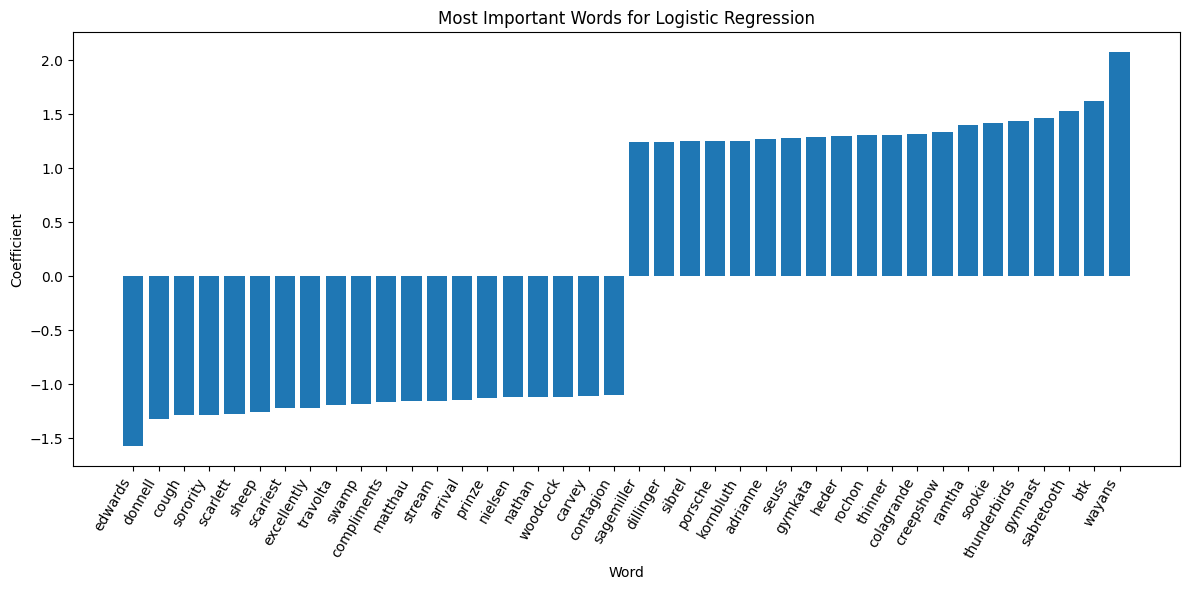

In [16]:
important_words = np.hstack([top_negative, top_positive])

plt.figure(figsize=(12, 6))
plt.bar(np.arange(40), coef[important_words])
plt.xticks(np.arange(40), feature_names[important_words], rotation=60, ha="right")
plt.xlabel("Word")
plt.ylabel("Coefficient")
plt.title("Most Important Words for Logistic Regression")
plt.tight_layout()
plt.show()

## 13. Stop words

Beberapa kata sangat sering muncul tetapi tidak terlalu membantu untuk klasifikasi, misalnya:
- the
- is
- and
- of

Kata-kata seperti ini disebut **stop words**.  
Scikit-learn menyediakan daftar stop words bahasa Inggris melalui `ENGLISH_STOP_WORDS`.

Menghapus stop words kadang membantu, tetapi tidak selalu.  
Karena itu, hasilnya tetap perlu diuji secara empiris.

In [17]:
print("Jumlah stop words bawaan scikit-learn:", len(ENGLISH_STOP_WORDS))
print("Contoh stop words:")
print(list(sorted(ENGLISH_STOP_WORDS))[:40])

Jumlah stop words bawaan scikit-learn: 318
Contoh stop words:
['a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amoungst', 'amount', 'an', 'and', 'another', 'any', 'anyhow', 'anyone', 'anything', 'anyway', 'anywhere', 'are', 'around', 'as', 'at', 'back', 'be', 'became', 'because', 'become', 'becomes']


In [18]:
vect = CountVectorizer(min_df=5, stop_words="english")
X_train = vect.fit_transform(text_train)
X_test = vect.transform(text_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

print("Training accuracy:", round(logreg.score(X_train, y_train), 3))
print("Test accuracy    :", round(logreg.score(X_test, y_test), 3))
print("Jumlah fitur setelah stop words:", X_train.shape[1])

Training accuracy: 0.964
Test accuracy    : 0.242
Jumlah fitur setelah stop words: 44223


## 14. N-grams

Pada bag-of-words biasa, model hanya melihat kata tunggal (**unigram**).  
Masalahnya, beberapa makna muncul dari gabungan kata, misalnya:

- "not good"
- "very bad"
- "highly recommended"

Untuk menangkap pola seperti ini, kita bisa memakai **n-grams**:
- unigram → 1 kata
- bigram → 2 kata berurutan
- trigram → 3 kata berurutan

Kita akan mencoba `ngram_range=(1,2)` agar model memakai unigram dan bigram sekaligus.

In [19]:
vect = CountVectorizer(min_df=5, ngram_range=(1, 2))
X_train = vect.fit_transform(text_train)
X_test = vect.transform(text_test)

print("X_train shape dengan unigram + bigram:", X_train.shape)

X_train shape dengan unigram + bigram: (75000, 377417)


In [20]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

print("Training accuracy:", round(logreg.score(X_train, y_train), 3))
print("Test accuracy    :", round(logreg.score(X_test, y_test), 3))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training accuracy: 0.995
Test accuracy    : 0.209


## 15. Menggunakan Pipeline dan GridSearchCV

Karena ada beberapa parameter yang ingin diuji sekaligus, kita bisa menggabungkan vectorizer dan model ke dalam **Pipeline**, lalu mencari kombinasi terbaik dengan **GridSearchCV**.

Parameter yang akan diuji:
- `min_df`
- `ngram_range`
- `C` pada Logistic Regression

In [21]:
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("logreg", LogisticRegression(max_iter=1000))
])

In [22]:
param_grid = {
    "vect__min_df": [1, 5],
    "vect__ngram_range": [(1, 1), (1, 2)],
    "logreg__C": [0.1, 1, 10]
}

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("logreg", LogisticRegression(max_iter=1000))
])

param_grid = {
    "vect__max_features": [1000, 3000],
    "vect__ngram_range": [(1, 1), (1, 2)],
    "logreg__C": [0.1, 1, 10]
}

grid = GridSearchCV(pipe, param_grid, cv=3, n_jobs=-1)
grid.fit(small_train, small_y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", round(grid.best_score_, 3))
print("Test score:", round(grid.score(text_test, y_test), 3))

Best parameters: {'logreg__C': 0.1, 'vect__max_features': 3000, 'vect__ngram_range': (1, 1)}
Best cross-validation score: 0.614
Test score: 0.166


In [27]:
results = pd.DataFrame(grid.cv_results_)

results = results[[
    "param_vect__max_features",
    "param_vect__ngram_range",
    "param_logreg__C",
    "mean_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

display(results.head(10))

,param_vect__max_features,param_vect__ngram_range,param_logreg__C,mean_test_score,rank_test_score
2,3000,"(1, 1)",0.1,0.614395,1
3,3000,"(1, 2)",0.1,0.609598,2
7,3000,"(1, 2)",1.0,0.590396,3
6,3000,"(1, 1)",1.0,0.589594,4
0,1000,"(1, 1)",0.1,0.587997,5
10,3000,"(1, 1)",10.0,0.581595,6
11,3000,"(1, 2)",10.0,0.577995,7
1,1000,"(1, 2)",0.1,0.577993,8
4,1000,"(1, 1)",1.0,0.549998,9
5,1000,"(1, 2)",1.0,0.531997,10


## 16. TF-IDF

Selain menghitung jumlah kata mentah dengan `CountVectorizer`, kita juga bisa memakai **TF-IDF**.

TF-IDF = **Term Frequency × Inverse Document Frequency**

Intuisi sederhananya:
- kata yang sering muncul dalam satu dokumen akan mendapat bobot tinggi
- tetapi jika kata itu muncul hampir di semua dokumen, bobotnya akan diturunkan

Dengan demikian, kata yang lebih informatif akan menjadi lebih penting.

In [28]:
tfidf = TfidfVectorizer(min_df=5)
X_train_tfidf = tfidf.fit_transform(text_train)
X_test_tfidf = tfidf.transform(text_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)

X_train_tfidf shape: (75000, 44532)


In [29]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train)

print("Training accuracy:", round(logreg.score(X_train_tfidf, y_train), 3))
print("Test accuracy    :", round(logreg.score(X_test_tfidf, y_test), 3))

Training accuracy: 0.79
Test accuracy    : 0.091


## 17. Melihat bobot kata pada model TF-IDF

Sama seperti sebelumnya, kita bisa melihat kata mana yang memiliki koefisien paling besar atau paling kecil pada model Logistic Regression.

In [30]:
feature_names = np.array(tfidf.get_feature_names_out())
coef = logreg.coef_[0]

top_positive = np.argsort(coef)[-20:]
top_negative = np.argsort(coef)[:20]

important_words_df = pd.DataFrame({
    "word": np.concatenate([feature_names[top_negative], feature_names[top_positive]]),
    "coefficient": np.concatenate([coef[top_negative], coef[top_positive]])
})

important_words_df

,word,coefficient
0,great,-3.493358
1,excellent,-3.409478
2,wonderful,-2.876332
3,perfect,-2.651995
4,today,-2.579985
5,amazing,-2.525847
6,best,-2.448056
7,favorite,-2.427583
8,loved,-2.236933
9,fantastic,-2.172265


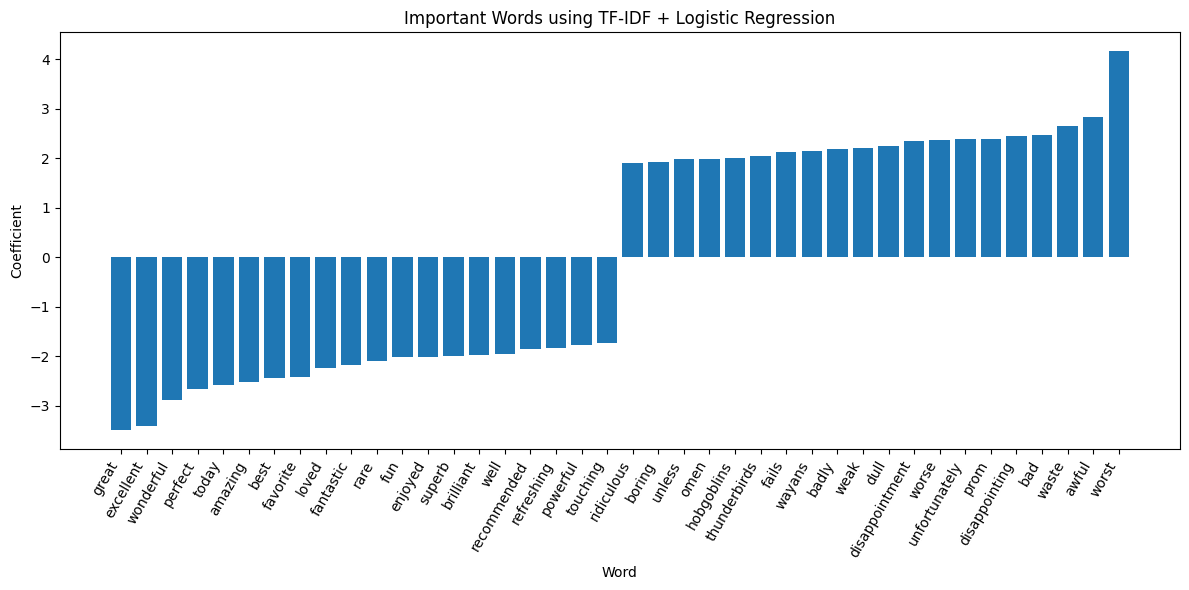

In [31]:
important_words = np.hstack([top_negative, top_positive])

plt.figure(figsize=(12, 6))
plt.bar(np.arange(40), coef[important_words])
plt.xticks(np.arange(40), feature_names[important_words], rotation=60, ha="right")
plt.xlabel("Word")
plt.ylabel("Coefficient")
plt.title("Important Words using TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

## 18. Mencari kata dengan IDF tertinggi dan terendah

Nilai IDF menunjukkan seberapa spesifik suatu kata terhadap dokumen tertentu.

- **IDF rendah** → kata muncul di banyak dokumen
- **IDF tinggi** → kata lebih jarang dan cenderung lebih spesifik

In [32]:
idf = tfidf.idf_
feature_names = np.array(tfidf.get_feature_names_out())

idf_df = pd.DataFrame({
    "term": feature_names,
    "idf": idf
}).sort_values("idf")

print("20 kata dengan IDF paling rendah:")
display(idf_df.head(20))

print("\n20 kata dengan IDF paling tinggi:")
display(idf_df.tail(20))

20 kata dengan IDF paling rendah:


,term,idf
39615,the,1.007683
1765,and,1.034991
27575,of,1.050325
40070,to,1.062300
39737,this,1.098832
20796,is,1.108861
20849,it,1.116877
19728,in,1.125849
39607,that,1.207956
5640,but,1.328721



20 kata dengan IDF paling tinggi:


,term,idf
5370,buchholz,10.433497
5496,bumming,10.433497
37943,strategist,10.433497
37946,stratham,10.433497
20020,inexistent,10.433497
19881,incurs,10.433497
20009,inequity,10.433497
19893,indefinite,10.433497
5504,bumptious,10.433497
22,100x,10.433497


## 19. Perbandingan beberapa pendekatan

Sekarang kita buat ringkasan sederhana untuk membandingkan beberapa representasi teks:
1. CountVectorizer standar
2. CountVectorizer dengan stop words
3. CountVectorizer dengan unigram + bigram
4. TF-IDF

In [35]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Pakai subset kecil supaya cepat
quick_train = text_train[:1500]
quick_test = text_test[:800]
quick_y_train = y_train[:1500]
quick_y_test = y_test[:800]

scores = []

# 1. CountVectorizer default
vect1 = CountVectorizer(max_features=2000)
X_train_1 = vect1.fit_transform(quick_train)
X_test_1 = vect1.transform(quick_test)

model1 = LogisticRegression(max_iter=300)
model1.fit(X_train_1, quick_y_train)
scores.append(("CountVectorizer default", model1.score(X_test_1, quick_y_test)))

# 2. CountVectorizer + stop words
vect2 = CountVectorizer(stop_words="english", max_features=2000)
X_train_2 = vect2.fit_transform(quick_train)
X_test_2 = vect2.transform(quick_test)

model2 = LogisticRegression(max_iter=300)
model2.fit(X_train_2, quick_y_train)
scores.append(("CountVectorizer + stop words", model2.score(X_test_2, quick_y_test)))

# 3. Bigram ringan
vect3 = CountVectorizer(ngram_range=(1, 2), max_features=3000)
X_train_3 = vect3.fit_transform(quick_train)
X_test_3 = vect3.transform(quick_test)

model3 = LogisticRegression(max_iter=300)
model3.fit(X_train_3, quick_y_train)
scores.append(("CountVectorizer + bigram", model3.score(X_test_3, quick_y_test)))

# 4. TF-IDF
vect4 = TfidfVectorizer(max_features=2000)
X_train_4 = vect4.fit_transform(quick_train)
X_test_4 = vect4.transform(quick_test)

model4 = LogisticRegression(max_iter=300)
model4.fit(X_train_4, quick_y_train)
scores.append(("TF-IDF", model4.score(X_test_4, quick_y_test)))

comparison = pd.DataFrame(scores, columns=["Method", "Test Accuracy"])
comparison = comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

comparison

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Method,Test Accuracy
0,CountVectorizer default,0.19500
1,CountVectorizer + stop words,0.17875
2,CountVectorizer + bigram,0.17000
3,TF-IDF,0.00125


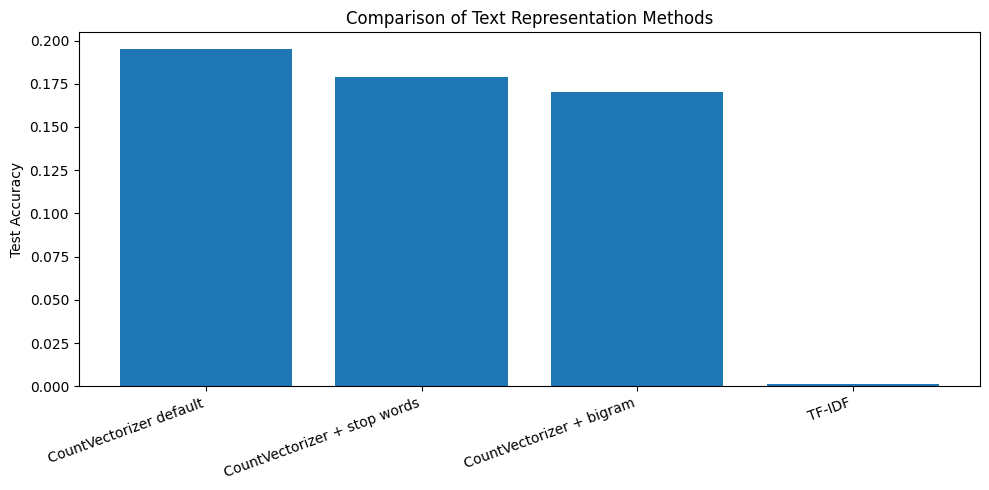

In [36]:
plt.figure(figsize=(10, 5))
plt.bar(comparison["Method"], comparison["Test Accuracy"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Test Accuracy")
plt.title("Comparison of Text Representation Methods")
plt.tight_layout()
plt.show()

## 20. Ringkasan konsep penting Chapter 7

Dari chapter ini, ada beberapa poin penting:

### a. Teks harus diubah menjadi angka
Model machine learning tidak bisa langsung memproses kalimat mentah.  
Karena itu, kita perlu mengubah dokumen menjadi representasi numerik.

### b. Bag-of-words adalah baseline yang kuat
Meskipun sederhana, pendekatan bag-of-words sering memberikan performa yang sangat baik untuk klasifikasi teks.

### c. CountVectorizer membangun vocabulary
Setiap kata unik menjadi fitur.  
Dokumen direpresentasikan sebagai jumlah kemunculan kata.

### d. `min_df` membantu mengurangi noise
Kata yang terlalu jarang muncul sering kali tidak membantu model, sehingga bisa dibuang.

### e. N-grams menangkap frasa
Bigram dan trigram membantu model memahami kombinasi kata seperti "not good" atau "very bad".

### f. TF-IDF memberi bobot yang lebih informatif
TF-IDF tidak hanya menghitung frekuensi kata, tetapi juga mempertimbangkan seberapa umum kata tersebut di seluruh dokumen.

### g. Model linear mudah diinterpretasikan
Koefisien pada Logistic Regression dapat digunakan untuk melihat kata mana yang paling berpengaruh terhadap prediksi.

## 21. Kesimpulan Chapter 7

Chapter ini menunjukkan bahwa pengolahan teks dalam machine learning pada dasarnya terdiri dari dua tahap utama:

1. **Mengubah teks menjadi fitur numerik**
2. **Melatih model klasifikasi pada fitur tersebut**

Melalui `CountVectorizer` dan `TfidfVectorizer`, teks dapat direpresentasikan sebagai matriks fitur berdimensi tinggi.  
Selanjutnya, model seperti Logistic Regression dapat digunakan untuk melakukan klasifikasi sentimen dengan performa yang baik.

Selain itu, chapter ini juga memperlihatkan bahwa pemilihan representasi teks sangat memengaruhi hasil model.  
Parameter seperti `min_df`, `stop_words`, dan `ngram_range` dapat mengubah kualitas fitur yang dihasilkan.  
Karena itu, pipeline dan grid search menjadi alat penting untuk mencari kombinasi terbaik secara sistematis.

Secara umum, chapter ini menjadi fondasi penting untuk memahami text mining, sentiment analysis, dan natural language processing berbasis machine learning klasik.

In [37]:
print("Chapter 7 selesai.")
print("Notebook ini telah membahas bag-of-words, CountVectorizer, TF-IDF, n-grams, dan klasifikasi sentimen pada data teks.")

Chapter 7 selesai.
Notebook ini telah membahas bag-of-words, CountVectorizer, TF-IDF, n-grams, dan klasifikasi sentimen pada data teks.
